[25Hz] range: 2025-09-13 00:37:21.100000 ~ 2025-09-13 09:33:19.900000 | NaT: 0.0
[200Hz] range: 2025-09-13 01:24:00 ~ 2025-09-13 09:07:02.519108 | NaT: 0.0

[ANALYSIS RANGE] 2025-09-13 01:24:00 ~ 2025-09-13 09:07:02.519108
Scheduled segments in range: 16


/tmp/ipython-input-2705307205.py:143: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dt_min = pd.to_datetime(dt_min).floor("H")
/tmp/ipython-input-2705307205.py:144: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dt_max = pd.to_datetime(dt_max).ceil("H")
/tmp/ipython-input-2705307205.py:145: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range(dt_min, dt_max, freq="H")



Saved:
  windows : /content/drive/MyDrive/Colab Notebooks/results_sched/S01_0913_sched_windows.csv | n = 96
  segments: /content/drive/MyDrive/Colab Notebooks/results_sched/S01_0913_sched_segments.csv | n = 16


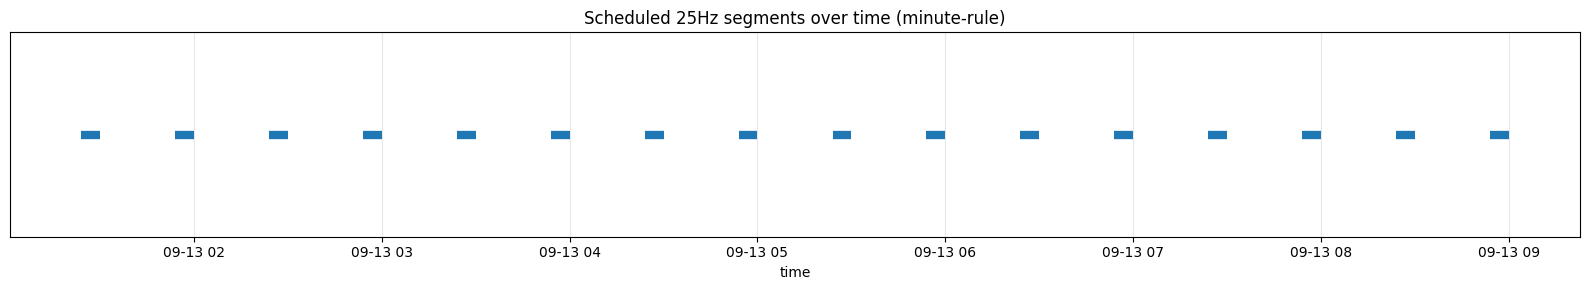

Figure saved: /content/drive/MyDrive/Colab Notebooks/results_sched/S01_0913_sched_timeline.png


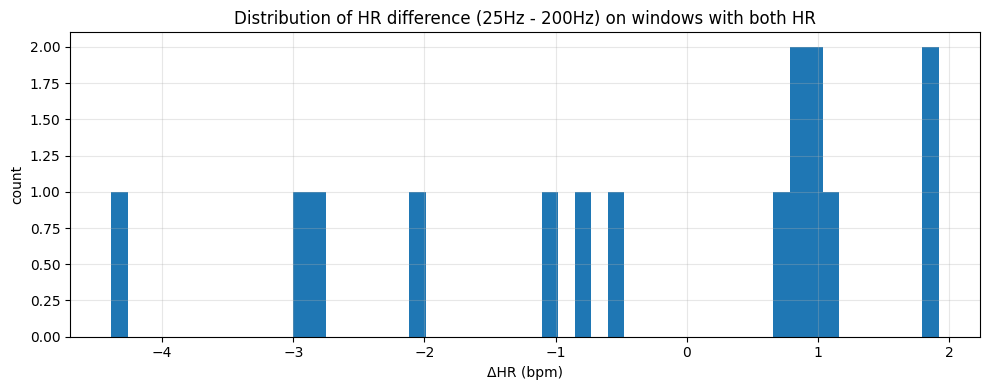

Figure saved: /content/drive/MyDrive/Colab Notebooks/results_sched/S01_0913_sched_dhr_hist.png

==================== SUMMARY ====================
Segments: 16
Mean segment coverage (expected-rate):
  25Hz: 0.3638888888888889  | median: 0.0
  200Hz: 1.0076927083333334  | median: 1.007673611111111

HR agreement (windows with both HR):
  n_pairs: 15
  mean(25-200): -0.3591382814173935
  std: 1.9351847165854514
  MAE: 1.5819307304336907
Done.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
CFG = {
    "FILE_25":  "/content/drive/MyDrive/Colab Notebooks/RealPPG/E0001_2.csv",
    "FILE_200": "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw2.csv",

    # 25Hz columns
    "TS_COL_25": "timestamp",   # epoch ms (anchor)
    "TIME_COL_25": "time",      # 'mm:ss.t' offset within hour
    "PPG_COL_25": "ppg",
    "TS25_IS_UTC": True,        # epoch(ms)가 UTC면 True

    # 200Hz (header none): col0=relative_us, col1=ppg
    "READ200_HEADER_NONE": True,
    "T_COL_200": 0,
    "PPG_COL_200": 1,
    "ABS_START_200": "2025-09-13 01:24:00",  # KST 기준 200Hz 시작

    # sampling (지표 계산용)
    "FS_25": 25.0,
    "FS_200": 200.0,

    # 스케줄: 매 시각 24~30, 54~60(=다음시각 00)
    "SCHED": [
        {"start_min": 24, "end_min": 30},  # [24,30)
        {"start_min": 54, "end_min": 60},  # [54,60)
    ],

    # 분석 시간 범위(관심 구간) - 필요 없으면 None으로 두면 전체에서 자동 생성
    "RANGE_START": None,   # "2025-09-13 01:24:00"
    "RANGE_END":   None,   # "2025-09-13 07:00:00"

    # window inside each scheduled segment
    "WIN_SEC": 60,
    "STEP_SEC": 60,

    # quality rule (일단 SNR은 느슨하게 두는게 좋습니다)
    "MIN_COV_25": 0.50,     # 버스트 내부라도 결측/이상치 있을 수 있어 완화
    "MIN_COV_200": 0.90,
    "MIN_SNR_DB": -10.0,    # ★ 25Hz가 -5dB 주변이면 0dB는 과하게 빡빡함

    # output
    "OUT_DIR": "/content/drive/MyDrive/Colab Notebooks/results_sched",
    "RUN_ID": "S01_0913_sched",
}
os.makedirs(CFG["OUT_DIR"], exist_ok=True)

# ============================================================
# Helpers
# ============================================================
def parse_mmss_t(s):
    s = str(s)
    if ":" not in s:
        return np.nan
    m_str, sec_str = s.split(":", 1)
    try:
        m = int(float(m_str))
        sec = float(sec_str)
        return m * 60.0 + sec
    except:
        return np.nan

def build_dt25(df):
    t_ms = pd.to_numeric(df[CFG["TS_COL_25"]], errors="coerce")
    if CFG["TS25_IS_UTC"]:
        anchor = (pd.to_datetime(t_ms, unit="ms", utc=True, errors="coerce")
                    .dt.tz_convert("Asia/Seoul").dt.tz_localize(None))
    else:
        anchor = pd.to_datetime(t_ms, unit="ms", errors="coerce")

    off_sec = df[CFG["TIME_COL_25"]].map(parse_mmss_t).astype(float)
    dt = anchor + pd.to_timedelta(off_sec, unit="s")
    return pd.Series(dt).reset_index(drop=True)

def build_dt200(df200):
    t = pd.to_numeric(df200.iloc[:, CFG["T_COL_200"]], errors="coerce").to_numpy()
    t_valid = t[np.isfinite(t)]
    if len(t_valid) == 0:
        raise ValueError("200Hz time col has no valid values.")
    t0 = t_valid[0]
    dt = pd.to_datetime(CFG["ABS_START_200"]) + pd.to_timedelta((t - t0), unit="us")
    return pd.Series(dt).reset_index(drop=True)

def band_snr_simple(x, fs, f_lo=0.7, f_hi=3.0):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) < int(fs * 5):
        return np.nan
    x = x - np.nanmean(x)
    n = len(x)
    w = np.hanning(n)
    X = np.fft.rfft(x * w)
    P = (np.abs(X) ** 2)
    f = np.fft.rfftfreq(n, d=1/fs)
    band = (f >= f_lo) & (f <= f_hi)
    out  = ((f >= 0.1) & (f < f_lo)) | ((f > f_hi) & (f <= 8.0))
    pb = P[band].sum()
    po = P[out].sum()
    if po <= 0:
        return np.nan
    return 10.0 * np.log10((pb + 1e-12) / (po + 1e-12))

def hr_from_fft(x, fs, bpm_lo=40, bpm_hi=180):
    x = np.asarray(x, float)
    if len(x) < int(fs * 10):
        return np.nan
    if np.isfinite(x).mean() < 0.8:
        return np.nan
    x = x - np.nanmean(x)
    n = len(x)
    w = np.hanning(n)
    X = np.fft.rfft(x * w)
    P = (np.abs(X) ** 2)
    f = np.fft.rfftfreq(n, d=1/fs)
    f_lo = bpm_lo / 60.0
    f_hi = bpm_hi / 60.0
    m = (f >= f_lo) & (f <= f_hi)
    if m.sum() < 3:
        return np.nan
    fp = f[m][np.argmax(P[m])]
    return float(fp * 60.0)

def rolling_windows(t0, t1, win_sec, step_sec):
    cur = pd.to_datetime(t0)
    end = pd.to_datetime(t1)
    win = pd.to_timedelta(win_sec, "s")
    step = pd.to_timedelta(step_sec, "s")
    while cur + win <= end:
        yield cur, cur + win
        cur = cur + step

def make_schedule_segments(dt_min, dt_max):
    """
    dt_min~dt_max 사이 모든 시간에 대해
    매 시각 [24,30), [54,60) 세그먼트를 생성.
    """
    dt_min = pd.to_datetime(dt_min).floor("H")
    dt_max = pd.to_datetime(dt_max).ceil("H")
    hours = pd.date_range(dt_min, dt_max, freq="H")

    segs = []
    for h in hours:
        for k, rule in enumerate(CFG["SCHED"]):
            s = h + pd.to_timedelta(rule["start_min"], "m")
            e = h + pd.to_timedelta(rule["end_min"], "m")
            # end_min=60이면 다음시각 00이 됨(정상)
            segs.append({"seg_start": s, "seg_end": e, "slot": k})
    return segs

def in_any_schedule(dt_series):
    """
    dt가 스케줄 구간(24-30, 54-60)에 해당하면 True.
    """
    dt = pd.to_datetime(dt_series)
    minute = dt.dt.minute + dt.dt.second/60.0
    m = np.zeros(len(dt), dtype=bool)
    for rule in CFG["SCHED"]:
        m |= (minute >= rule["start_min"]) & (minute < rule["end_min"])
    return m

# ============================================================
# 1) Load & build time
# ============================================================
df25 = pd.read_csv(CFG["FILE_25"])
dt25 = build_dt25(df25)
x25 = pd.to_numeric(df25[CFG["PPG_COL_25"]], errors="coerce").to_numpy()

if CFG["READ200_HEADER_NONE"]:
    df200 = pd.read_csv(CFG["FILE_200"], header=None)
else:
    df200 = pd.read_csv(CFG["FILE_200"])
dt200 = build_dt200(df200)
x200 = pd.to_numeric(df200.iloc[:, CFG["PPG_COL_200"]], errors="coerce").to_numpy()

print("[25Hz] range:", dt25.min(), "~", dt25.max(), "| NaT:", dt25.isna().mean())
print("[200Hz] range:", dt200.min(), "~", dt200.max(), "| NaT:", pd.isna(dt200).mean())

# ============================================================
# 2) Determine analysis range
# ============================================================
t0 = pd.to_datetime(CFG["RANGE_START"]) if CFG["RANGE_START"] else max(dt25.min(), dt200.min())
t1 = pd.to_datetime(CFG["RANGE_END"])   if CFG["RANGE_END"]   else min(dt25.max(), dt200.max())
if t1 <= t0:
    raise ValueError("No overlap between 25Hz and 200Hz time ranges. Check ABS_START_200 and dt25 build.")

print("\n[ANALYSIS RANGE]", t0, "~", t1)

# ============================================================
# 3) Create scheduled segments
# ============================================================
segs = make_schedule_segments(t0, t1)
# 범위 밖 세그먼트 제거
segs = [s for s in segs if (s["seg_end"] > t0) and (s["seg_start"] < t1)]
print("Scheduled segments in range:", len(segs))

# ============================================================
# 4) For each scheduled segment, compute window metrics
# ============================================================
rows_win = []
rows_seg = []

for seg_id, seg in enumerate(segs):
    s = max(seg["seg_start"], t0)
    e = min(seg["seg_end"], t1)
    if e <= s:
        continue

    # within segment mask
    m25_seg = (dt25 >= s) & (dt25 < e)
    m200_seg = (dt200 >= s) & (dt200 < e)

    dt25_seg = pd.to_datetime(dt25[m25_seg].reset_index(drop=True))
    x25_seg = x25[m25_seg.to_numpy()]

    dt200_seg = pd.to_datetime(dt200[m200_seg].reset_index(drop=True))
    x200_seg = x200[m200_seg.to_numpy()]

    # segment coverage (expected samples)
    dur_sec = (e - s).total_seconds()
    exp25 = int(round(dur_sec * CFG["FS_25"]))
    exp200 = int(round(dur_sec * CFG["FS_200"]))
    cov25_seg = (len(x25_seg) / exp25) if exp25 > 0 else 0.0
    cov200_seg = (len(x200_seg) / exp200) if exp200 > 0 else 0.0

    # window metrics
    win_count = 0
    good25 = 0
    good200 = 0
    both = 0
    dhrs = []

    for w0, w1 in rolling_windows(s, e, CFG["WIN_SEC"], CFG["STEP_SEC"]):
        m25 = ((dt25_seg >= w0) & (dt25_seg < w1)).to_numpy(dtype=bool)
        m200 = ((dt200_seg >= w0) & (dt200_seg < w1)).to_numpy(dtype=bool)

        seg25 = x25_seg[m25] if m25.any() else np.array([])
        seg200w = x200_seg[m200] if m200.any() else np.array([])

        # "정말 샘플이 있는지" 기반 coverage (윈도우 내부)
        cov25 = float(np.isfinite(seg25).mean()) if len(seg25) else 0.0
        cov200 = float(np.isfinite(seg200w).mean()) if len(seg200w) else 0.0

        snr25 = band_snr_simple(seg25, CFG["FS_25"]) if len(seg25) else np.nan
        snr200 = band_snr_simple(seg200w, CFG["FS_200"]) if len(seg200w) else np.nan

        hr25 = hr_from_fft(seg25, CFG["FS_25"]) if len(seg25) else np.nan
        hr200 = hr_from_fft(seg200w, CFG["FS_200"]) if len(seg200w) else np.nan

        d_hr = np.nan
        if np.isfinite(hr25) and np.isfinite(hr200):
            d_hr = float(hr25 - hr200)
            dhrs.append(d_hr)

        ok25 = int((cov25 >= CFG["MIN_COV_25"]) and np.isfinite(snr25) and (snr25 >= CFG["MIN_SNR_DB"]))
        ok200 = int((cov200 >= CFG["MIN_COV_200"]) and np.isfinite(snr200) and (snr200 >= CFG["MIN_SNR_DB"]))

        good25 += ok25
        good200 += ok200
        both += int(ok25 == 1 and ok200 == 1)
        win_count += 1

        rows_win.append({
            "run_id": CFG["RUN_ID"],
            "seg_id": seg_id,
            "slot": seg["slot"],
            "seg_start": s,
            "seg_end": e,
            "w0": w0, "w1": w1,
            "cov25": cov25, "cov200": cov200,
            "snr25_db": snr25, "snr200_db": snr200,
            "hr25_bpm": hr25, "hr200_bpm": hr200,
            "d_hr_25_minus_200": d_hr,
            "ok25": ok25, "ok200": ok200,
        })

    dhrs = np.array(dhrs, float)
    rows_seg.append({
        "run_id": CFG["RUN_ID"],
        "seg_id": seg_id,
        "slot": seg["slot"],
        "seg_start": s,
        "seg_end": e,
        "dur_sec": dur_sec,
        "n25": len(x25_seg),
        "n200": len(x200_seg),
        "expected25": exp25,
        "expected200": exp200,
        "seg_cov25": cov25_seg,
        "seg_cov200": cov200_seg,
        "wins": win_count,
        "good25_wins": good25,
        "good200_wins": good200,
        "both_good_wins": both,
        "mean_dhr": float(np.nanmean(dhrs)) if dhrs.size else np.nan,
        "std_dhr": float(np.nanstd(dhrs)) if dhrs.size else np.nan,
        "mae_dhr": float(np.nanmean(np.abs(dhrs))) if dhrs.size else np.nan,
    })

df_win = pd.DataFrame(rows_win)
df_seg = pd.DataFrame(rows_seg)

# ============================================================
# 5) Save
# ============================================================
win_path = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_windows.csv")
seg_path = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_segments.csv")
df_win.to_csv(win_path, index=False)
df_seg.to_csv(seg_path, index=False)

print("\nSaved:")
print("  windows :", win_path, "| n =", len(df_win))
print("  segments:", seg_path, "| n =", len(df_seg))

# ============================================================
# 6) Plot: scheduled segments timeline
# ============================================================
plt.figure(figsize=(16,3))
y = np.zeros(len(df_seg))
plt.hlines(y, df_seg["seg_start"], df_seg["seg_end"], linewidth=6)
plt.title("Scheduled 25Hz segments over time (minute-rule)")
plt.xlabel("time")
plt.yticks([])
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig1 = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_timeline.png")
plt.savefig(fig1, dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved:", fig1)

# ============================================================
# 7) HR difference histogram (both HR exist)
# ============================================================
valid = df_win.dropna(subset=["d_hr_25_minus_200"])
if len(valid):
    plt.figure(figsize=(10,4))
    plt.hist(valid["d_hr_25_minus_200"], bins=50)
    plt.title("Distribution of HR difference (25Hz - 200Hz) on windows with both HR")
    plt.xlabel("ΔHR (bpm)")
    plt.ylabel("count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    fig2 = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_dhr_hist.png")
    plt.savefig(fig2, dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure saved:", fig2)

# ============================================================
# 8) Quick summary
# ============================================================
print("\n==================== SUMMARY ====================")
print("Segments:", len(df_seg))
print("Mean segment coverage (expected-rate):")
print("  25Hz:", float(df_seg["seg_cov25"].mean()), " | median:", float(df_seg["seg_cov25"].median()))
print("  200Hz:", float(df_seg["seg_cov200"].mean()), " | median:", float(df_seg["seg_cov200"].median()))
if len(valid):
    print("\nHR agreement (windows with both HR):")
    print("  n_pairs:", len(valid))
    print("  mean(25-200):", float(valid["d_hr_25_minus_200"].mean()))
    print("  std:", float(valid["d_hr_25_minus_200"].std()))
    print("  MAE:", float(valid["d_hr_25_minus_200"].abs().mean()))
else:
    print("\nNo HR pairs found.")
print("Done.")


[25Hz] range: 2025-09-13 00:37:21.100000 ~ 2025-09-13 09:33:19.900000 | NaT: 0.0
[200Hz] range: 2025-09-13 01:24:00 ~ 2025-09-13 09:07:02.519108 | NaT: 0.0

[ANALYSIS RANGE] 2025-09-13 01:24:00 ~ 2025-09-13 07:00:00
  25Hz n: 99000  | 200Hz n: 4063024
Scheduled segments in night: 12
Saved segments: /content/drive/MyDrive/Colab Notebooks/results_sched_full/S01_0913_sched_full_segments.csv

Saved windows: /content/drive/MyDrive/Colab Notebooks/results_sched_full/S01_0913_sched_full_windows.csv | n_windows = 72

Scheduled Analysis: S01_0913_sched_full
Night: 2025-09-13 01:24:00 ~ 2025-09-13 07:00:00

[25Hz resample valid-ratio]
mean: 0.17 | median: 0.00

[25Hz duplicate ratio (dt duplication severity)]
mean: 0.14 | median: 0.00

[200Hz expected coverage]
mean: 1.00 | median: 1.00

[SNR stats (dB)]
25Hz  mean: -4.18 | std: 4.67
200Hz mean: 1.96 | std: 4.28

[Quality windows]
Good 25Hz:  10/72 (13.9%)
Good 200Hz: 72/72 (100.0%)
Both good:  10/72

[HR agreement (windows with both HR)]
n_pair

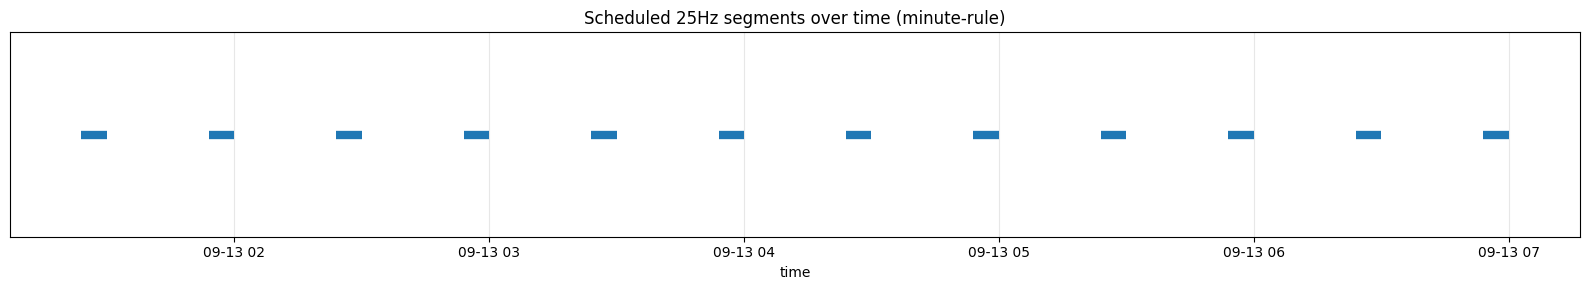

Figure saved: /content/drive/MyDrive/Colab Notebooks/results_sched_full/S01_0913_sched_full_timeline.png


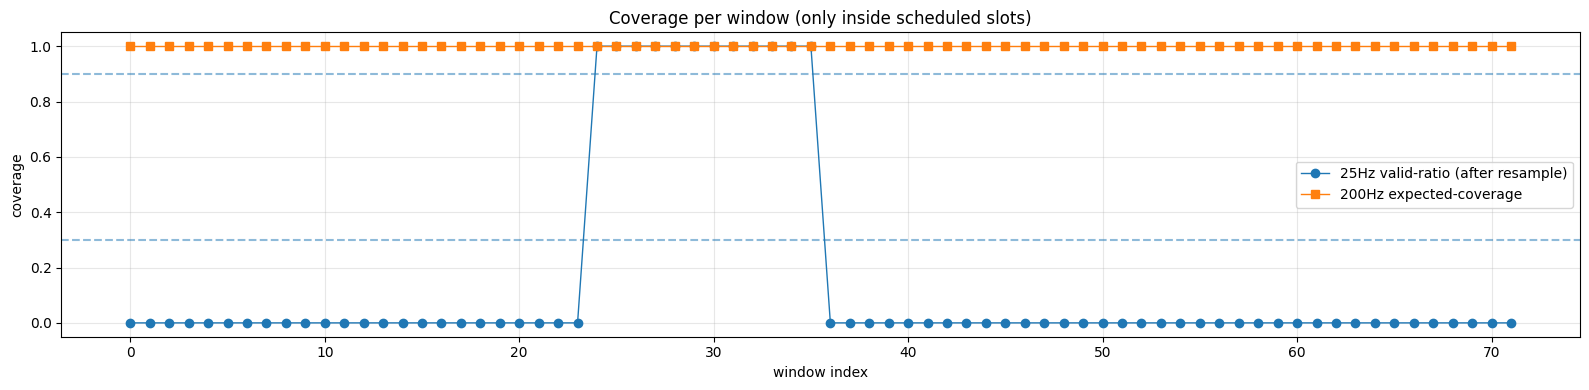

Figure saved: /content/drive/MyDrive/Colab Notebooks/results_sched_full/S01_0913_sched_full_coverage.png


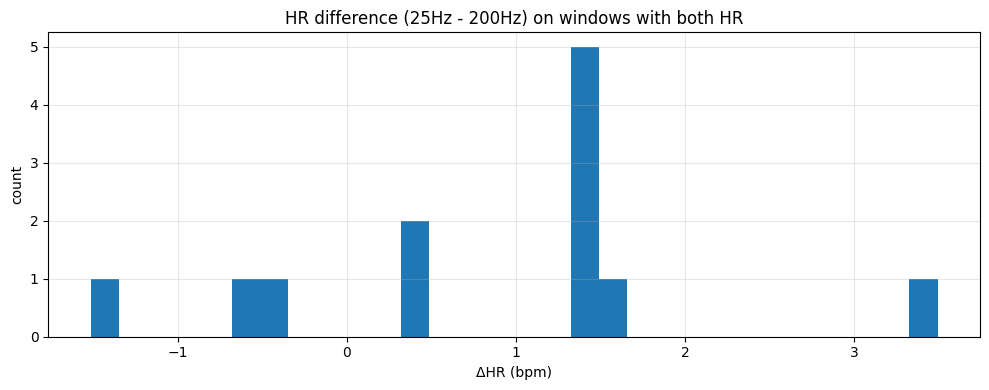

Figure saved: /content/drive/MyDrive/Colab Notebooks/results_sched_full/S01_0913_sched_full_dhr_hist.png


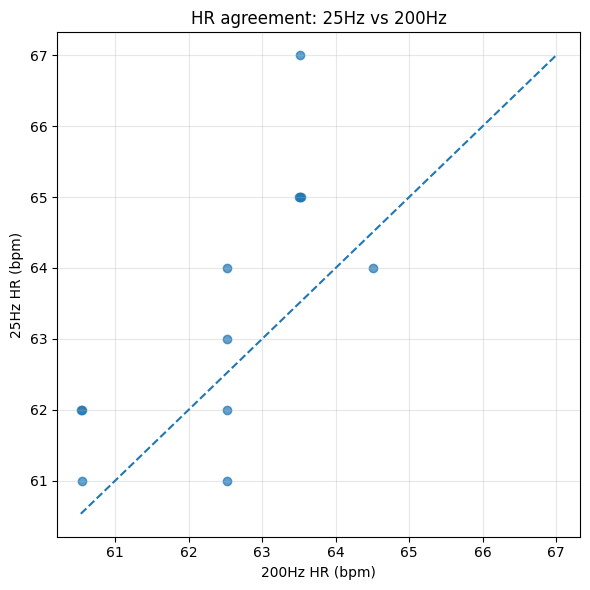

Figure saved: /content/drive/MyDrive/Colab Notebooks/results_sched_full/S01_0913_sched_full_hr_scatter.png

Done.


In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FULL SCRIPT (copy & run)
#  - 25Hz: burst/scheduled (24-30, 54-60)
#  - 25Hz time-axis issue fixed by: (epoch ms anchor) + (mm:ss.t offset)
#  - HR/SNR computed ONLY after uniform resampling to 25Hz grid per window
#  - coverage for 25Hz uses valid_ratio after resampling (0~1)
# ============================================================

# --------------------------
# CONFIG
# --------------------------
CFG = {
    # input
    "FILE_25":  "/content/drive/MyDrive/Colab Notebooks/RealPPG/E0001_2.csv",
    "FILE_200": "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw2.csv",

    # 25Hz columns
    "TS_COL_25": "timestamp",  # epoch ms (1.7e12)
    "TIME_COL_25": "time",     # "mm:ss.t" (within-hour offset)
    "PPG_COL_25": "ppg",
    "TS25_IS_UTC": True,       # epoch(ms) is UTC -> convert to KST

    # 200Hz file format
    "READ200_HEADER_NONE": True,   # ppgRaw2.csv has no header
    "T_COL_200": 0,                # col0 = relative time (often us ticks)
    "PPG_COL_200": 1,              # col1 = ppg
    "ABS_START_200": "2025-09-13 01:24:00",  # start datetime (KST)

    # sampling rates
    "FS_25": 25.0,
    "FS_200": 200.0,

    # analysis range
    "NIGHT_START": "2025-09-13 01:24:00",
    "NIGHT_END":   "2025-09-13 07:00:00",

    # scheduled measurement rule per hour: [24,30), [54,60)
    "SCHED": [
        {"start_min": 24, "end_min": 30},
        {"start_min": 54, "end_min": 60},
    ],

    # window settings (inside scheduled slots only)
    "WIN_SEC": 60,
    "STEP_SEC": 60,

    # resampling & QC
    "MAX_GAP_SEC_25": 2.0,         # max interpolation gap allowed (sec)
    "MIN_VALID_RATIO_25": 0.30,    # valid ratio threshold after resample
    "MIN_COV_EXPECT_200": 0.90,    # expected-coverage for 200Hz (n/expected)
    "MIN_SNR_DB": -10.0,           # allow low SNR for 25Hz (tune later)

    # output
    "OUT_DIR": "/content/drive/MyDrive/Colab Notebooks/results_sched_full",
    "RUN_ID": "S01_0913_sched_full",
}
os.makedirs(CFG["OUT_DIR"], exist_ok=True)


# ============================================================
# Helpers
# ============================================================
def parse_mmss_t(s):
    """'mm:ss.t' -> seconds within hour"""
    s = str(s)
    if ":" not in s:
        return np.nan
    m_str, sec_str = s.split(":", 1)
    try:
        m = int(float(m_str))
        sec = float(sec_str)
        return m * 60.0 + sec
    except:
        return np.nan


def build_dt25(df):
    """
    dt25 = anchor(epoch ms) + offset(mm:ss.t).
    Then sort by dt.
    Returns: dt25_sorted (Series), order (np array)
    """
    t_ms = pd.to_numeric(df[CFG["TS_COL_25"]], errors="coerce")
    if CFG["TS25_IS_UTC"]:
        anchor = (pd.to_datetime(t_ms, unit="ms", utc=True, errors="coerce")
                    .dt.tz_convert("Asia/Seoul")
                    .dt.tz_localize(None))
    else:
        anchor = pd.to_datetime(t_ms, unit="ms", errors="coerce")

    off_sec = df[CFG["TIME_COL_25"]].map(parse_mmss_t).astype(float)
    dt = anchor + pd.to_timedelta(off_sec, unit="s")
    dt = pd.Series(dt).reset_index(drop=True)

    order = np.argsort(dt.to_numpy(dtype="datetime64[ns]"))
    dt = dt.iloc[order].reset_index(drop=True)
    return dt, order


def build_dt200(df200):
    """
    col0 is assumed relative time ticks (often us).
    Convert to absolute datetime using ABS_START_200.
    """
    t = pd.to_numeric(df200.iloc[:, CFG["T_COL_200"]], errors="coerce").to_numpy()
    t_valid = t[np.isfinite(t)]
    if len(t_valid) == 0:
        raise ValueError("200Hz time col has no valid values.")

    # Use first valid as zero
    t0 = t_valid[0]
    dt = pd.to_datetime(CFG["ABS_START_200"]) + pd.to_timedelta((t - t0), unit="us")
    dt = pd.Series(dt).reset_index(drop=True)
    return dt


def abs_cut_by_dt(df, dt, t0, t1):
    """safe cut for Series/DatetimeIndex"""
    t0 = pd.to_datetime(t0); t1 = pd.to_datetime(t1)
    dt = pd.to_datetime(pd.Series(dt), errors="coerce")
    m = ((dt >= t0) & (dt <= t1)).to_numpy(dtype=bool)
    return df.iloc[m].reset_index(drop=True), dt.iloc[m].reset_index(drop=True)


def make_schedule_segments(dt_min, dt_max):
    """
    Create scheduled segments between dt_min~dt_max based on CFG["SCHED"].
    """
    dt_min = pd.to_datetime(dt_min).floor("h")
    dt_max = pd.to_datetime(dt_max).ceil("h")
    hours = pd.date_range(dt_min, dt_max, freq="h")

    segs = []
    for h in hours:
        for slot, rule in enumerate(CFG["SCHED"]):
            s = h + pd.to_timedelta(rule["start_min"], "m")
            e = h + pd.to_timedelta(rule["end_min"], "m")
            segs.append({"seg_start": s, "seg_end": e, "slot": slot})

    # keep only those overlapping overall range
    segs = [g for g in segs if (g["seg_end"] > dt_min) and (g["seg_start"] < dt_max)]
    return segs


def rolling_windows(t0, t1, win_sec, step_sec):
    cur = pd.to_datetime(t0)
    end = pd.to_datetime(t1)
    win = pd.to_timedelta(win_sec, "s")
    step = pd.to_timedelta(step_sec, "s")
    while cur + win <= end:
        yield cur, cur + win
        cur = cur + step


def band_snr_simple(x, fs, f_lo=0.7, f_hi=3.0):
    """proxy SNR: band power / out-of-band power (dB)"""
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) < int(fs * 5):
        return np.nan
    x = x - np.nanmean(x)
    n = len(x)
    w = np.hanning(n)
    X = np.fft.rfft(x * w)
    P = (np.abs(X) ** 2)
    f = np.fft.rfftfreq(n, d=1/fs)

    band = (f >= f_lo) & (f <= f_hi)
    out  = ((f >= 0.1) & (f < f_lo)) | ((f > f_hi) & (f <= 8.0))

    pb = P[band].sum()
    po = P[out].sum()
    if po <= 0:
        return np.nan
    return 10.0 * np.log10((pb + 1e-12) / (po + 1e-12))


def hr_from_fft(x, fs, bpm_lo=40, bpm_hi=180):
    """simple FFT peak HR (requires uniform sampling!)"""
    x = np.asarray(x, float)
    if len(x) < int(fs * 10):
        return np.nan
    if np.isfinite(x).mean() < 0.8:
        return np.nan

    x = x - np.nanmean(x)
    n = len(x)
    w = np.hanning(n)
    X = np.fft.rfft(x * w)
    P = (np.abs(X) ** 2)
    f = np.fft.rfftfreq(n, d=1/fs)

    f_lo = bpm_lo / 60.0
    f_hi = bpm_hi / 60.0
    m = (f >= f_lo) & (f <= f_hi)
    if m.sum() < 3:
        return np.nan
    fp = f[m][np.argmax(P[m])]
    return float(fp * 60.0)


def cov_expected_clamped(n_samples, fs, win_sec):
    """expected-coverage = n / (fs*win_sec), clamped to [0,1]"""
    exp = int(round(fs * win_sec))
    if exp <= 0:
        return 0.0
    return float(min(1.0, n_samples / exp))


def resample_uniform(dt, x, fs, win_start, win_end, max_gap_sec=2.0):
    """
    Convert irregular/duplicated dt to uniform fs grid in [win_start, win_end).
      - duplicates merged by mean
      - reindexed on uniform grid
      - time interpolation limited by max_gap_sec (in samples)
    Returns:
      x_u, valid_ratio, dup_ratio
    """
    dt = pd.to_datetime(pd.Series(dt), errors="coerce")
    x = pd.to_numeric(pd.Series(x), errors="coerce")

    m = (dt >= win_start) & (dt < win_end) & dt.notna()
    dt = dt[m].reset_index(drop=True)
    x = x[m].reset_index(drop=True)

    n_out = int(round(fs * (pd.to_datetime(win_end) - pd.to_datetime(win_start)).total_seconds()))
    if len(dt) == 0:
        return np.full(n_out, np.nan), 0.0, 0.0

    dup_ratio = 1.0 - (dt.nunique() / max(1, len(dt)))

    s = pd.Series(x.to_numpy(), index=dt)
    s = s.groupby(level=0).mean().sort_index()

    step_ms = int(round(1000.0 / fs))
    grid = pd.date_range(win_start, win_end, freq=f"{step_ms}ms", inclusive="left")
    s2 = s.reindex(grid)

    limit = int(round(max_gap_sec * fs))
    s2 = s2.interpolate(method="time", limit=limit, limit_direction="both")

    x_u = s2.to_numpy(dtype=float)
    valid_ratio = float(np.isfinite(x_u).mean())
    return x_u, valid_ratio, float(dup_ratio)


# ============================================================
# 1) Load
# ============================================================
df25_raw = pd.read_csv(CFG["FILE_25"])

if CFG["READ200_HEADER_NONE"]:
    df200_raw = pd.read_csv(CFG["FILE_200"], header=None)
else:
    df200_raw = pd.read_csv(CFG["FILE_200"])

# ============================================================
# 2) Build dt25 + sort, dt200
# ============================================================
dt25, order25 = build_dt25(df25_raw)
df25 = df25_raw.iloc[order25].reset_index(drop=True)
x25 = pd.to_numeric(df25[CFG["PPG_COL_25"]], errors="coerce").to_numpy()

dt200 = build_dt200(df200_raw)
df200 = df200_raw.reset_index(drop=True)
x200 = pd.to_numeric(df200.iloc[:, CFG["PPG_COL_200"]], errors="coerce").to_numpy()

print("[25Hz] range:", dt25.min(), "~", dt25.max(), "| NaT:", float(pd.isna(dt25).mean()))
print("[200Hz] range:", dt200.min(), "~", dt200.max(), "| NaT:", float(pd.isna(dt200).mean()))

# ============================================================
# 3) Cut to night range
# ============================================================
df25, dt25 = abs_cut_by_dt(df25, dt25, CFG["NIGHT_START"], CFG["NIGHT_END"])
df200, dt200 = abs_cut_by_dt(df200, dt200, CFG["NIGHT_START"], CFG["NIGHT_END"])
x25 = pd.to_numeric(df25[CFG["PPG_COL_25"]], errors="coerce").to_numpy()
x200 = pd.to_numeric(df200.iloc[:, CFG["PPG_COL_200"]], errors="coerce").to_numpy()

print("\n[ANALYSIS RANGE]", CFG["NIGHT_START"], "~", CFG["NIGHT_END"])
print("  25Hz n:", len(df25), " | 200Hz n:", len(df200))

# ============================================================
# 4) Scheduled segments in night
# ============================================================
t0 = pd.to_datetime(CFG["NIGHT_START"])
t1 = pd.to_datetime(CFG["NIGHT_END"])

segs = make_schedule_segments(t0, t1)
# clip to [t0,t1]
segs = [{"seg_start": max(g["seg_start"], t0),
         "seg_end":   min(g["seg_end"], t1),
         "slot": g["slot"]}
        for g in segs
        if min(g["seg_end"], t1) > max(g["seg_start"], t0)]

print("Scheduled segments in night:", len(segs))

# save segments list
seg_df0 = pd.DataFrame(segs)
seg_path = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_segments.csv")
seg_df0.to_csv(seg_path, index=False)
print("Saved segments:", seg_path)

# ============================================================
# 5) Window analysis inside segments
# ============================================================
rows = []
for seg_id, seg in enumerate(segs):
    s = seg["seg_start"]
    e = seg["seg_end"]
    dur_sec = (e - s).total_seconds()

    # segment expected coverage (diagnostic)
    exp25_seg = int(round(CFG["FS_25"] * dur_sec))
    exp200_seg = int(round(CFG["FS_200"] * dur_sec))

    m25_seg = (dt25 >= s) & (dt25 < e)
    m200_seg = (dt200 >= s) & (dt200 < e)

    n25_seg = int(m25_seg.sum())
    n200_seg = int(m200_seg.sum())

    seg_cov25 = (n25_seg / exp25_seg) if exp25_seg > 0 else 0.0
    seg_cov200 = (n200_seg / exp200_seg) if exp200_seg > 0 else 0.0

    for w0, w1 in rolling_windows(s, e, CFG["WIN_SEC"], CFG["STEP_SEC"]):

        # ---- 25Hz: resample to uniform grid (critical) ----
        seg25_u, vr25, dup25 = resample_uniform(
            dt25, x25, CFG["FS_25"], w0, w1, max_gap_sec=CFG["MAX_GAP_SEC_25"]
        )
        cov25 = vr25  # valid ratio after resample (0~1)

        # ---- 200Hz: expected coverage (continuous) ----
        m200_w = ((dt200 >= w0) & (dt200 < w1)).to_numpy(dtype=bool)
        seg200_w = x200[m200_w] if m200_w.any() else np.array([])
        cov200 = cov_expected_clamped(len(seg200_w), CFG["FS_200"], CFG["WIN_SEC"])

        # SQI
        snr25 = band_snr_simple(seg25_u, CFG["FS_25"]) if vr25 > 0 else np.nan
        snr200 = band_snr_simple(seg200_w, CFG["FS_200"]) if len(seg200_w) else np.nan

        # HR (uniform sampling assumed)
        hr25 = hr_from_fft(seg25_u, CFG["FS_25"]) if vr25 >= CFG["MIN_VALID_RATIO_25"] else np.nan
        hr200 = hr_from_fft(seg200_w, CFG["FS_200"]) if len(seg200_w) else np.nan

        d_hr = np.nan
        if np.isfinite(hr25) and np.isfinite(hr200):
            d_hr = float(hr25 - hr200)

        ok25 = int((vr25 >= CFG["MIN_VALID_RATIO_25"]) and np.isfinite(snr25) and (snr25 >= CFG["MIN_SNR_DB"]))
        ok200 = int((cov200 >= CFG["MIN_COV_EXPECT_200"]) and np.isfinite(snr200) and (snr200 >= CFG["MIN_SNR_DB"]))

        rows.append({
            "run_id": CFG["RUN_ID"],
            "seg_id": seg_id,
            "slot": seg["slot"],
            "seg_start": s, "seg_end": e,
            "seg_cov25_exp": seg_cov25,
            "seg_cov200_exp": seg_cov200,
            "seg_n25": n25_seg,
            "seg_n200": n200_seg,

            "w0": w0, "w1": w1,

            # window level
            "cov25_validratio": cov25,
            "dup25_ratio": dup25,
            "cov200_exp": cov200,
            "n200": int(len(seg200_w)),

            "snr25_db": snr25,
            "snr200_db": snr200,
            "hr25_bpm": hr25,
            "hr200_bpm": hr200,
            "d_hr_25_minus_200": d_hr,
            "ok25": ok25,
            "ok200": ok200,
        })

out = pd.DataFrame(rows)
win_path = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_windows.csv")
out.to_csv(win_path, index=False)
print("\nSaved windows:", win_path, "| n_windows =", len(out))

# ============================================================
# 6) Summary
# ============================================================
print("\n" + "="*60)
print("Scheduled Analysis:", CFG["RUN_ID"])
print("Night:", CFG["NIGHT_START"], "~", CFG["NIGHT_END"])
print("="*60)

if len(out) == 0:
    print("No windows. Check schedule / time alignment.")
else:
    print("\n[25Hz resample valid-ratio]")
    print(f"mean: {out['cov25_validratio'].mean():.2f} | median: {out['cov25_validratio'].median():.2f}")
    print("\n[25Hz duplicate ratio (dt duplication severity)]")
    print(f"mean: {out['dup25_ratio'].mean():.2f} | median: {out['dup25_ratio'].median():.2f}")

    print("\n[200Hz expected coverage]")
    print(f"mean: {out['cov200_exp'].mean():.2f} | median: {out['cov200_exp'].median():.2f}")

    print("\n[SNR stats (dB)]")
    print(f"25Hz  mean: {out['snr25_db'].mean():.2f} | std: {out['snr25_db'].std():.2f}")
    print(f"200Hz mean: {out['snr200_db'].mean():.2f} | std: {out['snr200_db'].std():.2f}")

    print("\n[Quality windows]")
    print(f"Good 25Hz:  {out['ok25'].sum()}/{len(out)} ({out['ok25'].mean():.1%})")
    print(f"Good 200Hz: {out['ok200'].sum()}/{len(out)} ({out['ok200'].mean():.1%})")
    print(f"Both good:  {((out['ok25']==1)&(out['ok200']==1)).sum()}/{len(out)}")

    valid_hr = out.dropna(subset=["d_hr_25_minus_200"])
    print("\n[HR agreement (windows with both HR)]")
    if len(valid_hr):
        print("n_pairs:", len(valid_hr))
        print(f"mean(25-200): {valid_hr['d_hr_25_minus_200'].mean():.2f} bpm")
        print(f"std:          {valid_hr['d_hr_25_minus_200'].std():.2f} bpm")
        print(f"MAE:          {valid_hr['d_hr_25_minus_200'].abs().mean():.2f} bpm")
    else:
        print("No HR pairs found (likely due to low valid-ratio in 25Hz).")

# ============================================================
# 7) Plots
# ============================================================
if len(out):
    # (a) scheduled timeline
    seg_df = pd.DataFrame(segs).sort_values("seg_start").reset_index(drop=True)
    plt.figure(figsize=(16, 3))
    y = np.zeros(len(seg_df))
    plt.hlines(y, seg_df["seg_start"], seg_df["seg_end"], linewidth=6)
    plt.title("Scheduled 25Hz segments over time (minute-rule)")
    plt.xlabel("time")
    plt.yticks([])
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    p = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_timeline.png")
    plt.savefig(p, dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure saved:", p)

    # (b) 25Hz valid-ratio and 200Hz expected coverage
    plt.figure(figsize=(16, 4))
    plt.plot(out.index, out["cov25_validratio"], marker="o", linewidth=1, label="25Hz valid-ratio (after resample)")
    plt.plot(out.index, out["cov200_exp"], marker="s", linewidth=1, label="200Hz expected-coverage")
    plt.axhline(CFG["MIN_VALID_RATIO_25"], linestyle="--", alpha=0.5)
    plt.axhline(CFG["MIN_COV_EXPECT_200"], linestyle="--", alpha=0.5)
    plt.title("Coverage per window (only inside scheduled slots)")
    plt.xlabel("window index")
    plt.ylabel("coverage")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    p = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_coverage.png")
    plt.savefig(p, dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure saved:", p)

    # (c) HR diff histogram
    valid = out.dropna(subset=["d_hr_25_minus_200"])
    if len(valid):
        plt.figure(figsize=(10, 4))
        plt.hist(valid["d_hr_25_minus_200"], bins=30)
        plt.title("HR difference (25Hz - 200Hz) on windows with both HR")
        plt.xlabel("ΔHR (bpm)")
        plt.ylabel("count")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        p = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_dhr_hist.png")
        plt.savefig(p, dpi=150, bbox_inches="tight")
        plt.show()
        print("Figure saved:", p)
    else:
        print("No valid HR diffs to plot.")

    # (d) HR scatter
    valid2 = out.dropna(subset=["hr25_bpm", "hr200_bpm"])
    if len(valid2):
        plt.figure(figsize=(6, 6))
        plt.scatter(valid2["hr200_bpm"], valid2["hr25_bpm"], alpha=0.7)
        lo = float(np.nanmin([valid2["hr200_bpm"].min(), valid2["hr25_bpm"].min()]))
        hi = float(np.nanmax([valid2["hr200_bpm"].max(), valid2["hr25_bpm"].max()]))
        plt.plot([lo, hi], [lo, hi], linestyle="--")
        plt.xlabel("200Hz HR (bpm)")
        plt.ylabel("25Hz HR (bpm)")
        plt.title("HR agreement: 25Hz vs 200Hz")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        p = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_hr_scatter.png")
        plt.savefig(p, dpi=150, bbox_inches="tight")
        plt.show()
        print("Figure saved:", p)
    else:
        print("No HR pairs for scatter plot.")

print("\nDone.")


[25Hz] range: 2025-09-13 00:37:21.100000 ~ 2025-09-13 09:33:19.900000 | NaT: 0.0
[200Hz] range: 2025-09-13 01:24:00 ~ 2025-09-13 09:07:02.519108 | NaT: 0.0

[ANALYSIS RANGE] 2025-09-13 01:24:00 ~ 2025-09-13 07:00:00
  25Hz n: 99000  | 200Hz n: 4063024
Scheduled segments in night: 12

Saved: /content/drive/MyDrive/Colab Notebooks/results_sched_v2/S01_0913_sched_v2_windows.csv | n_windows = 72

Scheduled Analysis: S01_0913_sched_v2
Night: 2025-09-13 01:24:00 ~ 2025-09-13 07:00:00

[Expected-coverage stats (window-level)]
25Hz  - mean: 0.41 | median: 0.00
200Hz - mean: 1.01 | median: 1.01

[Segment expected-coverage stats (slot-level)]
25Hz  - mean seg_cov: 0.41 | median seg_cov: 0.00
200Hz - mean seg_cov: 1.01 | median seg_cov: 1.01

[SNR stats (dB)]
25Hz  - mean: -4.79 | std: 1.78
200Hz - mean: 1.96 | std: 4.28

[Quality windows]
Good 25Hz:  12/72 (16.7%)
Good 200Hz: 72/72 (100.0%)
Both good:  12/72

[HR agreement (windows with both HR)]
n_pairs: 12
mean(25-200): 83.45 bpm
std:         

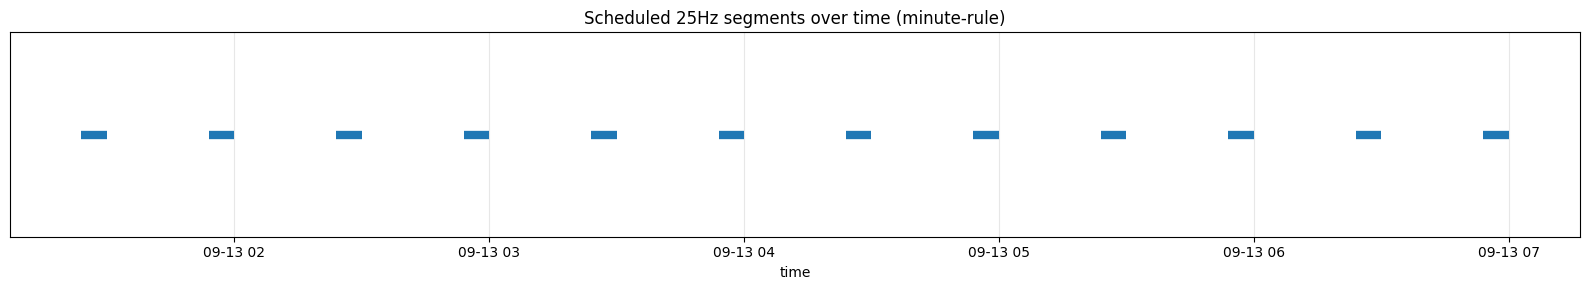

Figure saved: /content/drive/MyDrive/Colab Notebooks/results_sched_v2/S01_0913_sched_v2_timeline.png


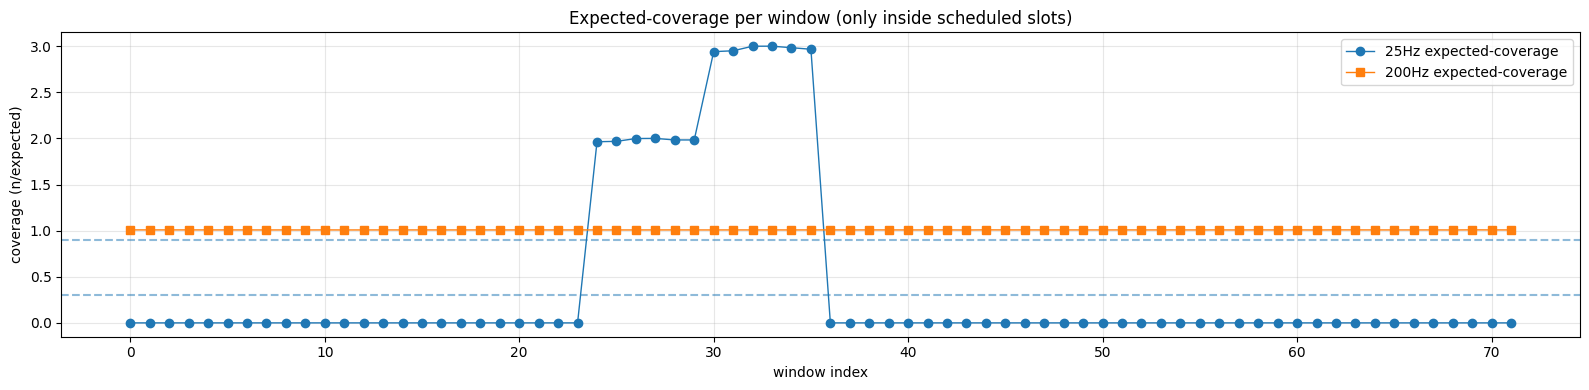

Figure saved: /content/drive/MyDrive/Colab Notebooks/results_sched_v2/S01_0913_sched_v2_cov_expected.png


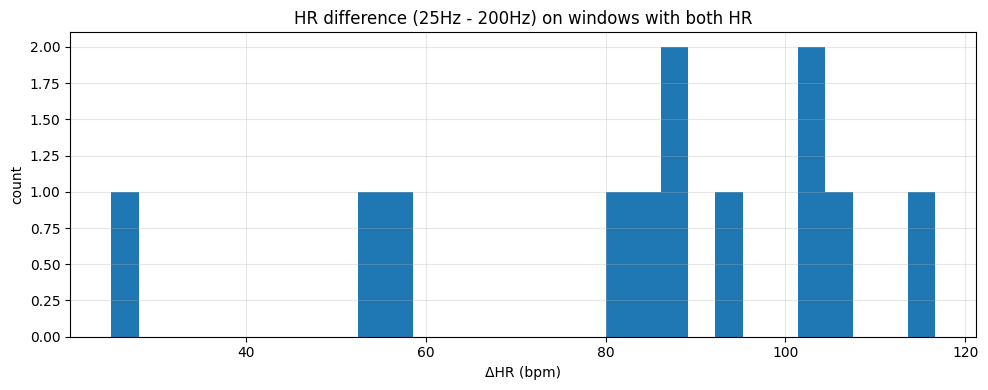

Figure saved: /content/drive/MyDrive/Colab Notebooks/results_sched_v2/S01_0913_sched_v2_dhr_hist.png

Done.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIG: "야간 하루" + "스케줄(24-30, 54-60) 버스트" 반영 버전
#   - 25Hz는 6분 슬롯 안에서도 누락이 많을 수 있으므로
#     coverage를 "expected 샘플 대비 실제 샘플 비율"로 계산합니다.
#   - 롤링윈도우는 "스케줄 슬롯 내부"에서만 생성합니다.
# ============================================================
CFG = {
    "FILE_25":  "/content/drive/MyDrive/Colab Notebooks/RealPPG/E0001_2.csv",
    "FILE_200": "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw2.csv",

    # 25Hz columns
    "TS_COL_25": "timestamp",   # epoch ms (anchor)
    "TIME_COL_25": "time",      # "mm:ss.t" 형태 (hour 내부 오프셋)
    "PPG_COL_25": "ppg",
    "TS25_IS_UTC": True,        # epoch(ms)가 UTC이면 True (KST로 변환)

    # 200Hz (header none): col0=relative_us, col1=ppg
    "READ200_HEADER_NONE": True,
    "T_COL_200": 0,
    "PPG_COL_200": 1,
    "ABS_START_200": "2025-09-13 01:24:00",  # KST 기준 200Hz 시작

    # sampling (지표 계산용)
    "FS_25": 25.0,
    "FS_200": 200.0,

    # 분석 구간 (원하시면 바꾸세요)
    "NIGHT_START": "2025-09-13 01:24:00",
    "NIGHT_END":   "2025-09-13 07:00:00",

    # 측정 스케줄: 매 시각 24~30, 54~60(=다음시각 00)
    # (윈도우는 슬롯 내부에서만 생성)
    "SCHED": [
        {"start_min": 24, "end_min": 30},  # [24,30)
        {"start_min": 54, "end_min": 60},  # [54,60)
    ],

    # 윈도우
    "WIN_SEC": 60,
    "STEP_SEC": 60,

    # 품질 룰(스케줄/누락 고려)
    # coverage는 "expected 대비 실제 샘플 비율"로 계산됨
    "MIN_COV_EXPECT_25": 0.30,   # ★ 6분 슬롯 안에 2분 정도만 있어도 살리려면 0.30~0.40 권장
    "MIN_COV_EXPECT_200": 0.90,
    "MIN_SNR_DB": -10.0,         # ★ 25Hz SNR이 -5 dB 주변이면 0은 너무 빡빡

    # 저장
    "OUT_DIR": "/content/drive/MyDrive/Colab Notebooks/results_sched_v2",
    "RUN_ID": "S01_0913_sched_v2",
}
os.makedirs(CFG["OUT_DIR"], exist_ok=True)

# ============================================================
# Helpers
# ============================================================
def parse_mmss_t(s):
    """'mm:ss.t' -> seconds within hour"""
    s = str(s)
    if ":" not in s:
        return np.nan
    m_str, sec_str = s.split(":", 1)
    try:
        m = int(float(m_str))
        sec = float(sec_str)
        return m * 60.0 + sec
    except:
        return np.nan

def build_dt25(df):
    """timestamp(epoch ms) + time(mm:ss.t offset) => absolute datetime(KST)"""
    t_ms = pd.to_numeric(df[CFG["TS_COL_25"]], errors="coerce")

    if CFG["TS25_IS_UTC"]:
        anchor = (pd.to_datetime(t_ms, unit="ms", utc=True, errors="coerce")
                    .dt.tz_convert("Asia/Seoul")
                    .dt.tz_localize(None))
    else:
        anchor = pd.to_datetime(t_ms, unit="ms", errors="coerce")

    off_sec = df[CFG["TIME_COL_25"]].map(parse_mmss_t).astype(float)
    dt = anchor + pd.to_timedelta(off_sec, unit="s")
    dt = pd.Series(dt).reset_index(drop=True)

    # 정렬 + 동시간 반복(같은 dt) 존재 가능 -> 그대로 두되 정렬은 해둠
    order = np.argsort(dt.to_numpy(dtype="datetime64[ns]"))
    dt = dt.iloc[order].reset_index(drop=True)
    return dt, order

def build_dt200(df200):
    """col0=relative_us(혹은 유사) -> ABS_START_200 기준 절대시간"""
    t = pd.to_numeric(df200.iloc[:, CFG["T_COL_200"]], errors="coerce").to_numpy()
    t_valid = t[np.isfinite(t)]
    if len(t_valid) == 0:
        raise ValueError("200Hz time col has no valid values.")
    t0 = t_valid[0]
    dt = pd.to_datetime(CFG["ABS_START_200"]) + pd.to_timedelta((t - t0), unit="us")
    dt = pd.Series(dt).reset_index(drop=True)
    return dt

def abs_cut_by_dt(df, dt, t0, t1):
    t0 = pd.to_datetime(t0); t1 = pd.to_datetime(t1)
    dt = pd.to_datetime(pd.Series(dt), errors="coerce")
    m = ((dt >= t0) & (dt <= t1)).to_numpy(dtype=bool)
    return df.iloc[m].reset_index(drop=True), dt.iloc[m].reset_index(drop=True)

def band_snr_simple(x, fs, f_lo=0.7, f_hi=3.0):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) < int(fs * 5):
        return np.nan
    x = x - np.nanmean(x)
    n = len(x)
    w = np.hanning(n)
    X = np.fft.rfft(x * w)
    P = (np.abs(X) ** 2)
    f = np.fft.rfftfreq(n, d=1/fs)
    band = (f >= f_lo) & (f <= f_hi)
    out  = ((f >= 0.1) & (f < f_lo)) | ((f > f_hi) & (f <= 8.0))
    pb = P[band].sum()
    po = P[out].sum()
    if po <= 0:
        return np.nan
    return 10.0 * np.log10((pb + 1e-12) / (po + 1e-12))

def hr_from_fft(x, fs, bpm_lo=40, bpm_hi=180):
    x = np.asarray(x, float)
    if len(x) < int(fs * 10):
        return np.nan
    if np.isfinite(x).mean() < 0.8:
        return np.nan
    x = x - np.nanmean(x)
    n = len(x)
    w = np.hanning(n)
    X = np.fft.rfft(x * w)
    P = (np.abs(X) ** 2)
    f = np.fft.rfftfreq(n, d=1/fs)
    f_lo = bpm_lo / 60.0
    f_hi = bpm_hi / 60.0
    m = (f >= f_lo) & (f <= f_hi)
    if m.sum() < 3:
        return np.nan
    fp = f[m][np.argmax(P[m])]
    return float(fp * 60.0)

def make_schedule_segments(dt_min, dt_max):
    """
    dt_min~dt_max 범위에서 스케줄 슬롯(24-30, 54-60)을 생성.
    """
    dt_min = pd.to_datetime(dt_min).floor("h")
    dt_max = pd.to_datetime(dt_max).ceil("h")
    hours = pd.date_range(dt_min, dt_max, freq="h")

    segs = []
    for h in hours:
        for slot, rule in enumerate(CFG["SCHED"]):
            s = h + pd.to_timedelta(rule["start_min"], "m")
            e = h + pd.to_timedelta(rule["end_min"], "m")
            segs.append({"seg_start": s, "seg_end": e, "slot": slot})
    # 범위 밖 제거
    segs = [g for g in segs if (g["seg_end"] > dt_min) and (g["seg_start"] < dt_max)]
    return segs

def rolling_windows(t0, t1, win_sec, step_sec):
    cur = pd.to_datetime(t0)
    end = pd.to_datetime(t1)
    win = pd.to_timedelta(win_sec, "s")
    step = pd.to_timedelta(step_sec, "s")
    while cur + win <= end:
        yield cur, cur + win
        cur = cur + step

def cov_expected(n_samples, fs, win_sec):
    exp = int(round(fs * win_sec))
    return float(n_samples / exp) if exp > 0 else 0.0

# ============================================================
# 1) Load
# ============================================================
df25_raw = pd.read_csv(CFG["FILE_25"])

if CFG["READ200_HEADER_NONE"]:
    df200_raw = pd.read_csv(CFG["FILE_200"], header=None)
else:
    df200_raw = pd.read_csv(CFG["FILE_200"])

# ============================================================
# 2) Build dt + sort (25Hz)
# ============================================================
dt25, order25 = build_dt25(df25_raw)
df25 = df25_raw.iloc[order25].reset_index(drop=True)
x25 = pd.to_numeric(df25[CFG["PPG_COL_25"]], errors="coerce").to_numpy()

dt200 = build_dt200(df200_raw)
df200 = df200_raw.reset_index(drop=True)
x200 = pd.to_numeric(df200.iloc[:, CFG["PPG_COL_200"]], errors="coerce").to_numpy()

print("[25Hz] range:", dt25.min(), "~", dt25.max(), "| NaT:", float(pd.isna(dt25).mean()))
print("[200Hz] range:", dt200.min(), "~", dt200.max(), "| NaT:", float(pd.isna(dt200).mean()))

# ============================================================
# 3) Night cut (analysis range)
# ============================================================
df25, dt25 = abs_cut_by_dt(df25, dt25, CFG["NIGHT_START"], CFG["NIGHT_END"])
df200, dt200 = abs_cut_by_dt(df200, dt200, CFG["NIGHT_START"], CFG["NIGHT_END"])

x25 = pd.to_numeric(df25[CFG["PPG_COL_25"]], errors="coerce").to_numpy()
x200 = pd.to_numeric(df200.iloc[:, CFG["PPG_COL_200"]], errors="coerce").to_numpy()

print("\n[ANALYSIS RANGE]", CFG["NIGHT_START"], "~", CFG["NIGHT_END"])
print("  25Hz n:", len(df25), " | 200Hz n:", len(df200))

# ============================================================
# 4) Make schedule segments within night
# ============================================================
t0 = pd.to_datetime(CFG["NIGHT_START"])
t1 = pd.to_datetime(CFG["NIGHT_END"])
segs = make_schedule_segments(t0, t1)
# night range로 clip
segs = [{"seg_start": max(g["seg_start"], t0),
         "seg_end":   min(g["seg_end"], t1),
         "slot": g["slot"]} for g in segs if min(g["seg_end"], t1) > max(g["seg_start"], t0)]
print("Scheduled segments in night:", len(segs))

# ============================================================
# 5) Window features (ONLY inside scheduled segments)
#    ★ coverage를 expected 대비 실제 샘플 비율로 계산
# ============================================================
rows = []
for seg_id, seg in enumerate(segs):
    s = seg["seg_start"]
    e = seg["seg_end"]

    # segment masks
    m25_seg = (dt25 >= s) & (dt25 < e)
    m200_seg = (dt200 >= s) & (dt200 < e)

    dt25_seg = pd.to_datetime(dt25[m25_seg].reset_index(drop=True))
    x25_seg  = x25[m25_seg.to_numpy()]

    dt200_seg = pd.to_datetime(dt200[m200_seg].reset_index(drop=True))
    x200_seg  = x200[m200_seg.to_numpy()]

    # segment-level expected coverage (6분 슬롯 내부 누락 진단용)
    dur_sec = (e - s).total_seconds()
    exp25_seg = int(round(CFG["FS_25"] * dur_sec))
    exp200_seg = int(round(CFG["FS_200"] * dur_sec))
    seg_cov25 = (len(x25_seg) / exp25_seg) if exp25_seg > 0 else 0.0
    seg_cov200 = (len(x200_seg) / exp200_seg) if exp200_seg > 0 else 0.0

    # windows within segment
    for w0, w1 in rolling_windows(s, e, CFG["WIN_SEC"], CFG["STEP_SEC"]):
        m25 = ((dt25_seg >= w0) & (dt25_seg < w1)).to_numpy(dtype=bool)
        m200 = ((dt200_seg >= w0) & (dt200_seg < w1)).to_numpy(dtype=bool)

        seg25 = x25_seg[m25] if m25.any() else np.array([])
        seg200w = x200_seg[m200] if m200.any() else np.array([])

        # ★ expected coverage
        cov25 = cov_expected(len(seg25), CFG["FS_25"], CFG["WIN_SEC"])
        cov200 = cov_expected(len(seg200w), CFG["FS_200"], CFG["WIN_SEC"])

        snr25 = band_snr_simple(seg25, CFG["FS_25"]) if len(seg25) else np.nan
        snr200 = band_snr_simple(seg200w, CFG["FS_200"]) if len(seg200w) else np.nan

        hr25 = hr_from_fft(seg25, CFG["FS_25"]) if len(seg25) else np.nan
        hr200 = hr_from_fft(seg200w, CFG["FS_200"]) if len(seg200w) else np.nan

        d_hr = np.nan
        if np.isfinite(hr25) and np.isfinite(hr200):
            d_hr = float(hr25 - hr200)

        ok25 = int((cov25 >= CFG["MIN_COV_EXPECT_25"]) and np.isfinite(snr25) and (snr25 >= CFG["MIN_SNR_DB"]))
        ok200 = int((cov200 >= CFG["MIN_COV_EXPECT_200"]) and np.isfinite(snr200) and (snr200 >= CFG["MIN_SNR_DB"]))

        rows.append({
            "run_id": CFG["RUN_ID"],
            "seg_id": seg_id,
            "slot": seg["slot"],
            "seg_start": s, "seg_end": e,
            "seg_cov25": seg_cov25, "seg_cov200": seg_cov200,

            "w0": w0, "w1": w1,
            "cov25_exp": cov25, "cov200_exp": cov200,
            "n25": int(len(seg25)), "n200": int(len(seg200w)),
            "snr25_db": snr25, "snr200_db": snr200,
            "hr25_bpm": hr25, "hr200_bpm": hr200,
            "d_hr_25_minus_200": d_hr,
            "ok25": ok25, "ok200": ok200,
        })

out = pd.DataFrame(rows)

out_path = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_windows.csv")
out.to_csv(out_path, index=False)
print("\nSaved:", out_path, "| n_windows =", len(out))

# ============================================================
# 6) Summary
# ============================================================
print("\n" + "="*60)
print(f"Scheduled Analysis: {CFG['RUN_ID']}")
print(f"Night: {CFG['NIGHT_START']} ~ {CFG['NIGHT_END']}")
print("="*60)

if len(out) == 0:
    print("No windows generated. Check schedule or time alignment.")
else:
    print("\n[Expected-coverage stats (window-level)]")
    print(f"25Hz  - mean: {out['cov25_exp'].mean():.2f} | median: {out['cov25_exp'].median():.2f}")
    print(f"200Hz - mean: {out['cov200_exp'].mean():.2f} | median: {out['cov200_exp'].median():.2f}")

    print("\n[Segment expected-coverage stats (slot-level)]")
    print(f"25Hz  - mean seg_cov: {out['seg_cov25'].mean():.2f} | median seg_cov: {out['seg_cov25'].median():.2f}")
    print(f"200Hz - mean seg_cov: {out['seg_cov200'].mean():.2f} | median seg_cov: {out['seg_cov200'].median():.2f}")

    print("\n[SNR stats (dB)]")
    print(f"25Hz  - mean: {out['snr25_db'].mean():.2f} | std: {out['snr25_db'].std():.2f}")
    print(f"200Hz - mean: {out['snr200_db'].mean():.2f} | std: {out['snr200_db'].std():.2f}")

    print("\n[Quality windows]")
    print(f"Good 25Hz:  {out['ok25'].sum()}/{len(out)} ({out['ok25'].mean():.1%})")
    print(f"Good 200Hz: {out['ok200'].sum()}/{len(out)} ({out['ok200'].mean():.1%})")
    print(f"Both good:  {((out['ok25']==1)&(out['ok200']==1)).sum()}/{len(out)}")

    valid_hr = out.dropna(subset=["d_hr_25_minus_200"])
    print("\n[HR agreement (windows with both HR)]")
    if len(valid_hr):
        print(f"n_pairs: {len(valid_hr)}")
        print(f"mean(25-200): {valid_hr['d_hr_25_minus_200'].mean():.2f} bpm")
        print(f"std:          {valid_hr['d_hr_25_minus_200'].std():.2f} bpm")
        print(f"MAE:          {valid_hr['d_hr_25_minus_200'].abs().mean():.2f} bpm")
    else:
        print("No HR pairs found.")

# ============================================================
# 7) Plots
# ============================================================
if len(out):
    # (a) schedule timeline
    seg_df = (out[["seg_id","seg_start","seg_end","slot","seg_cov25","seg_cov200"]]
              .drop_duplicates()
              .sort_values("seg_start")
              .reset_index(drop=True))
    plt.figure(figsize=(16, 3))
    y = np.zeros(len(seg_df))
    plt.hlines(y, seg_df["seg_start"], seg_df["seg_end"], linewidth=6)
    plt.title("Scheduled 25Hz segments over time (minute-rule)")
    plt.xlabel("time")
    plt.yticks([])
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    fig1 = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_timeline.png")
    plt.savefig(fig1, dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure saved:", fig1)

    # (b) expected coverage over windows
    plt.figure(figsize=(16, 4))
    plt.plot(out.index, out["cov25_exp"], marker="o", linewidth=1, label="25Hz expected-coverage")
    plt.plot(out.index, out["cov200_exp"], marker="s", linewidth=1, label="200Hz expected-coverage")
    plt.axhline(CFG["MIN_COV_EXPECT_25"], linestyle="--", alpha=0.5)
    plt.axhline(CFG["MIN_COV_EXPECT_200"], linestyle="--", alpha=0.5)
    plt.title("Expected-coverage per window (only inside scheduled slots)")
    plt.xlabel("window index")
    plt.ylabel("coverage (n/expected)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    fig2 = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_cov_expected.png")
    plt.savefig(fig2, dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure saved:", fig2)

    # (c) HR diff histogram
    valid = out.dropna(subset=["d_hr_25_minus_200"])
    if len(valid):
        plt.figure(figsize=(10, 4))
        plt.hist(valid["d_hr_25_minus_200"], bins=30)
        plt.title("HR difference (25Hz - 200Hz) on windows with both HR")
        plt.xlabel("ΔHR (bpm)")
        plt.ylabel("count")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        fig3 = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_dhr_hist.png")
        plt.savefig(fig3, dpi=150, bbox_inches="tight")
        plt.show()
        print("Figure saved:", fig3)

print("\nDone.")
